# **Business Understanding**

**Breast Cancer Wisconsin (Original)**
Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed from the data itself:

- Group 1: 367 instances (January 1989)
- Group 2:  70 instances (October 1989)
- Group 3:  31 instances (February 1990)
- Group 4:  17 instances (April 1990)
- Group 5:  48 instances (August 1990)
- Group 6:  49 instances (Updated January 1991)
- Group 7:  31 instances (June 1991)
- Group 8:  86 instances (November 1991)
-----------------------------------------
Total:   699 points (as of the donated datbase on 15 July 1992)

Note that the results summarized above in Past Usage refer to a dataset of size 369, while Group 1 has only 367 instances.  This is because it originally contained 369 instances; 2 were removed.  The following statements summarizes changes to the original Group 1's set of data:

Has Missing Values? Yes

*Variables*
1. Sample code number:            id number
2. Clump Thickness:               1 - 10
3. Uniformity of Cell Size:       1 - 10
4. Uniformity of Cell Shape:      1 - 10
5. Marginal Adhesion:             1 - 10
6. Single Epithelial Cell Size:   1 - 10
7. Bare Nuclei:                   1 - 10
8. Bland Chromatin:               1 - 10
9. Normal Nucleoli:               1 - 10
10. Mitoses:                       1 - 10
11. Class:                        (2 for benign, 4 for malignant)

[Data Source](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)

#### **Loading Libraries**

In [76]:
import pandas as pd # data manipulation and reading the dat as a dataframe
import numpy as np # for numerical analysis 
import seaborn as sns # visualizations
from sklearn.model_selection import train_test_split # we split the data to use it well 
from sklearn.metrics import r2_score, accuracy_score, classification_report,ConfusionMatrixDisplay, confusion_matrix, log_loss # evaluation metric  - R^2 
import matplotlib.pyplot as plt # aids in visualization
import xgboost as xgb
from sklearn.preprocessing import StandardScaler # scaling towards a mean = 0 and sd = 1

#### **Loading Data**

In [77]:
columns = [
    "ID",
    "Clump_thickness",
    "Uniformity_of_cell_size",
    "Uniformity_of_cell_shape",
    "Marginal_adhesion",
    "Single_epithelial_cell_size",
    "Bare_nuclei",
    "Bland_chromatin",
    "Normal_nucleoli",
    "Mitoses",
    "Diagnosis"
]

In [78]:
df = pd.read_csv("data/breast-cancer-wisconsin.data", header=None, names=columns)

Current features

In [79]:
df.head(3)

,ID,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Diagnosis
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2


# **Data Understanding**

In [80]:
rows, features = df.shape
print(f"Records: {rows} || Features: {features}")

Records: 699 || Features: 11


In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   ID                           699 non-null    int64
 1   Clump_thickness              699 non-null    int64
 2   Uniformity_of_cell_size      699 non-null    int64
 3   Uniformity_of_cell_shape     699 non-null    int64
 4   Marginal_adhesion            699 non-null    int64
 5   Single_epithelial_cell_size  699 non-null    int64
 6   Bare_nuclei                  699 non-null    str  
 7   Bland_chromatin              699 non-null    int64
 8   Normal_nucleoli              699 non-null    int64
 9   Mitoses                      699 non-null    int64
 10  Diagnosis                    699 non-null    int64
dtypes: int64(10), str(1)
memory usage: 60.2 KB


In [82]:
df['Bare_nuclei'].unique() # gets the unique values from the features

<StringArray>
['1', '10', '2', '4', '3', '9', '7', '?', '5', '8', '6']
Length: 11, dtype: str

Univariate Analysis

Bi-variate Analysis

Multi-variate Analysis

# **Data Preparation**

remove the '?' that exists in the column, 
The remedy of missing values is often dropping the row, when the number of missing values go beyond 70% we drop the entire column and if they are below 20% we trend to drop the missing row or perfomr imputation(you use an MCT to fill the missing values) => Investing Missing values the possibilities include: Missing at random, read this:[Handling missing values](https://www.datacamp.com/tutorial/techniques-to-handle-missing-data-values)

In [83]:
df['Bare_nuclei'] = df['Bare_nuclei'].replace('?', pd.NA)
# # since the missing values in 'Bare_nuclei' column are less than 2% we can drop the row
df['Bare_nuclei'] = pd.to_numeric(df['Bare_nuclei']) # converts to numerical form and reassigns the column 'Bare_nulcei' 
df = df.dropna() # dropping all rows containing the  missing values 

In [84]:
df.info()

<class 'pandas.DataFrame'>
Index: 683 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           683 non-null    int64  
 1   Clump_thickness              683 non-null    int64  
 2   Uniformity_of_cell_size      683 non-null    int64  
 3   Uniformity_of_cell_shape     683 non-null    int64  
 4   Marginal_adhesion            683 non-null    int64  
 5   Single_epithelial_cell_size  683 non-null    int64  
 6   Bare_nuclei                  683 non-null    float64
 7   Bland_chromatin              683 non-null    int64  
 8   Normal_nucleoli              683 non-null    int64  
 9   Mitoses                      683 non-null    int64  
 10  Diagnosis                    683 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 64.0 KB


encoding, we are basically mapping th evalues of 2 -> 0 and 4 -> 1

In [85]:
df['Diagnosis'] = df['Diagnosis'].map({2:0, 4:1}) # simple encoding to binary form i.e 0 and 1

In [86]:
counts = df['Diagnosis'].value_counts().sort_index()
counts

Diagnosis
0    444
1    239
Name: count, dtype: int64

Visualization of the binary classes

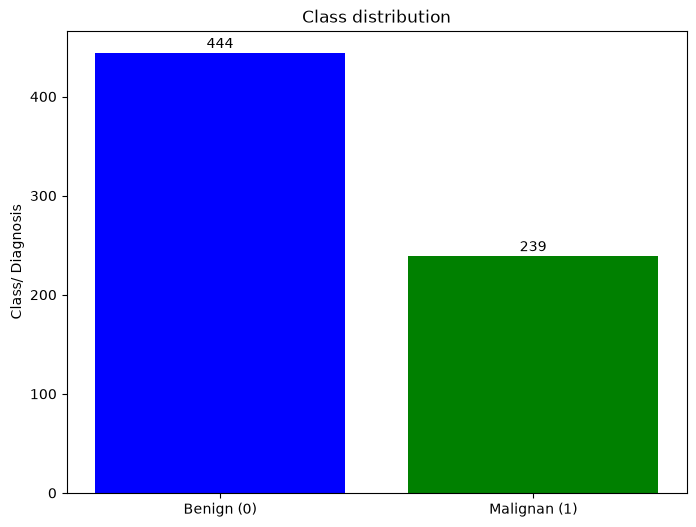

In [87]:
plt.figure(figsize=(8,6)) # usually manipulates the size
plt.bar(['Benign (0)','Malignan (1)'], counts.values, color=['blue', 'green'])
plt.title("Class distribution")
plt.ylabel('Number of samples')
plt.ylabel('Class/ Diagnosis')

for i, v in enumerate(counts.values):
    plt.text(i,v + 5, str(v), ha='center')

plt.show()

We notice that the 0 class (Benin) is more than  the 1 class (Malignant) 

splitting data

In [88]:
X = df.drop(['Diagnosis','ID'], axis = 1) # independent variable
y = df['Diagnosis'] # traget variable

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=42, 
    stratify= y # it will retain a constant proportion when splitting the two classes
)

# **Modeling**

In a DecisionTree we do not need to scale our data since the trees are scale invariant (Decision Thresholds exists)

In [90]:
n_estimators = 100 
learning_rate = 0.1 # ranges from 0.01 to 0.3
max_depth = 2

In [91]:
xgb_model = xgb.XGBClassifier(
    n_estemators = n_estimators, 
    learning_rate = learning_rate,
    max_depth = max_depth, 
    random_state=42, 
    eval_metric="logloss"
)

In [92]:
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=False
) # training the model

/home/josephridge/Documents/@software-engineering/@datascience/@emobilis/@dataScience-MAY/ML-Series/env/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:04:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_estemators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


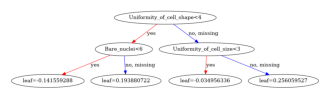

In [93]:
# plot our hm(x) decision tree
xgb.plot_tree(xgb_model)
plt.rcParams['figure.figsize'] = [25,14] 
plt.show()

In [94]:
y_pred = xgb_model.predict(X_test) # prediction
y_proba = xgb_model.predict_proba(X_test)[:,1]

In [95]:
y_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0])

In [96]:
y_proba

array([0.0016838 , 0.00150005, 0.01134685, 0.00150005, 0.98248416,
       0.00150005, 0.00434848, 0.05826848, 0.0016838 , 0.00624029,
       0.9988753 , 0.00286126, 0.00150005, 0.0016838 , 0.00375218,
       0.01732414, 0.00483541, 0.01043499, 0.01043499, 0.00324977,
       0.98620296, 0.92948514, 0.0016838 , 0.99917966, 0.00190758,
       0.9979255 , 0.00150005, 0.00150005, 0.00150005, 0.01294308,
       0.00817588, 0.00242112, 0.00150005, 0.00150005, 0.00150005,
       0.9652115 , 0.00483541, 0.9967546 , 0.0016838 , 0.0175755 ,
       0.96180207, 0.9905462 , 0.9973483 , 0.01968961, 0.9985152 ,
       0.00254934, 0.84328866, 0.00817588, 0.9844289 , 0.99125063,
       0.00150005, 0.00150005, 0.02820847, 0.00150005, 0.00150005,
       0.07874876, 0.99826705, 0.00817588, 0.0016838 , 0.9761687 ,
       0.99058294, 0.3091329 , 0.01272142, 0.00150005, 0.00324977,
       0.99762625, 0.00150005, 0.0020258 , 0.00541852, 0.99874675,
       0.0016838 , 0.00150005, 0.99825674, 0.0016838 , 0.00150

# **Evaluation**

Feature importance

In [97]:
accuracy  = accuracy_score(y_test, y_pred)
log_loss_output = log_loss(y_test, y_proba)

print(f"ACCURACY: {(accuracy *100):.2f}%")
print(f"log_loss: {(log_loss_output):.2f}")

ACCURACY: 95.12%
log_loss: 0.16


In [98]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       133
           1       0.93      0.93      0.93        72

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



In [99]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[128   5]
 [  5  67]]


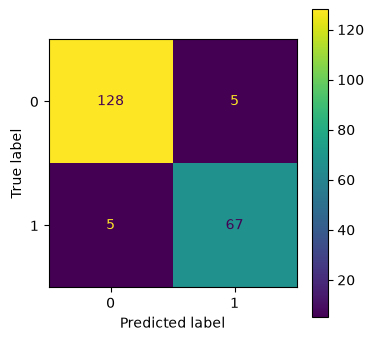

In [105]:
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
display.plot()
plt.rcParams['figure.figsize'] = [4,4] # manipulate the size of the figure
plt.show()

In [101]:
# loss cruves f the train and text per boosting round
results = xgb_model.evals_result()
train_curve = results["validation_0"]["logloss"]
test_curve = results["validation_1"]["logloss"]

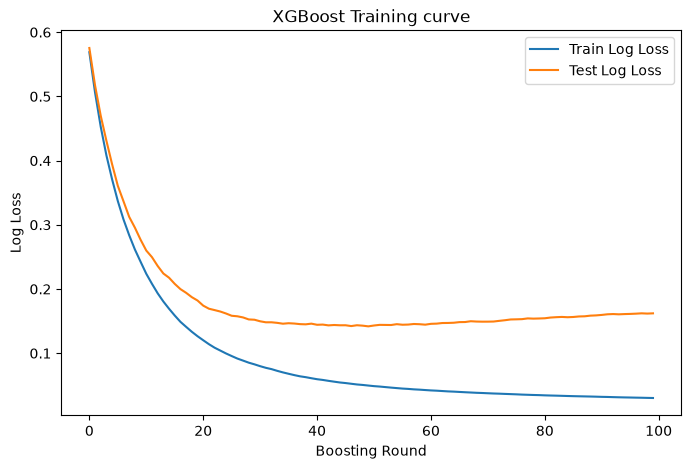

In [102]:
plt.figure(figsize=(8,5))
plt.plot(train_curve, label="Train Log Loss")
plt.plot(test_curve, label="Test Log Loss")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Training curve")
plt.legend()
plt.show()


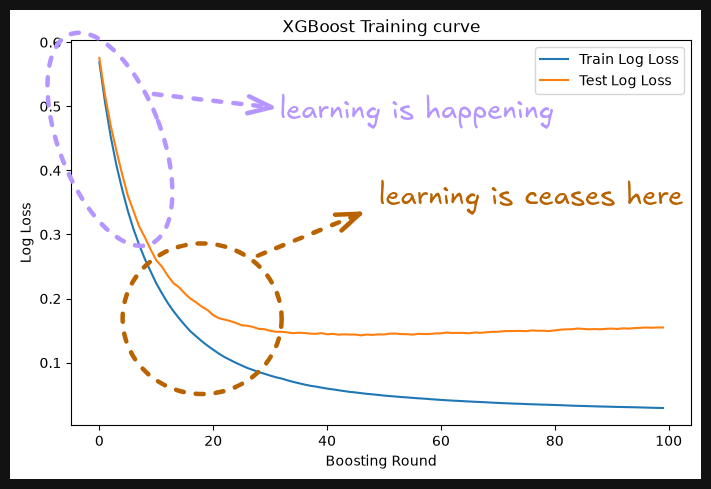

- steeper part defined more learning by the algo. to the point to which it start curving that is where learning reduces

In [103]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending= False)

print("\nTop 10 features: ")
print(importances.head(10))


Top 10 features: 
Uniformity_of_cell_shape       0.434652
Uniformity_of_cell_size        0.222571
Single_epithelial_cell_size    0.109427
Bare_nuclei                    0.086621
Bland_chromatin                0.044191
Clump_thickness                0.036654
Normal_nucleoli                0.025520
Mitoses                        0.021990
Marginal_adhesion              0.018374
dtype: float32


<Axes: >

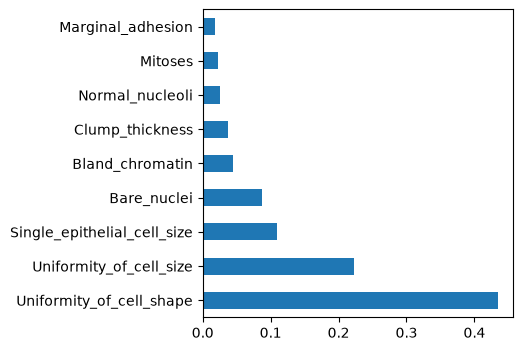

In [106]:
importances.head(10).plot(kind="barh")